In [9]:
import mujoco
import mediapy as media
import numpy as np

# Load the model

In [10]:
# Select the robot arm type, ur5e or panda
# robot_name = "ur5e"
robot_name = "panda"

if robot_name == "ur5e":
    xml_path = "universal_robots_ur5e/scene.xml"
else: 
    xml_path = "franka_emika_panda/scene01.xml"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

""

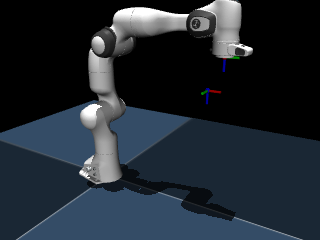

In [11]:
# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

renderer = mujoco.Renderer(model)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_SITE
# Make all sitegroup visiable 
scene_option.sitegroup[4] = 1

mujoco.mj_forward(model, data)
renderer.update_scene(data, scene_option=scene_option)
media.show_image(renderer.render())

# Target_id
mocap_id = model.body("target").mocapid[0]
# End-effector site we wish to control, in this case a site attached to the last
# link (wrist_3_link) of the robot.
site_id = model.site("attachment_site").id

# Define target trajectory

In [12]:
# Circle radius
r = 0.15
# Circle center x coordinates 
cx = 0.5 
# Circle center y coordinates
cy = 0.0
# Tranjectory freq
f = 0.5

def circle(t:float, r: float, h: float, k: float, f: float) -> np.ndarray:
    """
    Return the (x,y) coordinates of a circle with radius r centered at (h,k)
    as a function of time t and frequency f.
    """
    x = r * np.cos(2 * np.pi * f * t) + h
    y = r * np.sin(2 * np.pi * f * t) + k
    return np.array([x, y]) 

# Visualization helper

In [13]:
print(renderer.scene.ngeom)
print(renderer.scene.maxgeom)

58
10000


In [14]:
print(renderer.scene.geoms[0])

<MjvGeom
  camdist: 0.0
  category: 1
  dataid: 0
  emission: 0.0
  label: ''
  mat: array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)
  matid: 5
  modelrbound: 0.0
  objid: 0
  objtype: 5
  pos: array([0., 0., 0.], dtype=float32)
  reflectance: 0.0
  rgba: array([1., 1., 1., 1.], dtype=float32)
  segid: 0
  shininess: 0.5
  size: array([1.  , 1.  , 0.01], dtype=float32)
  specular: 0.5
  texcoord: 0
  transparent: 0
  type: 0
>


In [15]:
def add_visual_capsule(scene, point1, point2, radius, rgba):
    """Adds one capsule to an mjvScene."""
    if scene.ngeom >= scene.maxgeom:
        return
    scene.ngeom += 1  # increment ngeom
    # initialise a new capsule, add it to the scene using mjv_connector
    mujoco.mjv_initGeom(scene.geoms[scene.ngeom-1],
                      mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                      np.zeros(3), np.zeros(9), rgba.astype(np.float32))
    mujoco.mjv_connector(scene.geoms[scene.ngeom-1],
                       mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                       point1, point2)
  
def modify_scene(scn, target_traj, end_effector_traj):
    """Draw position trace"""
    if len(target_traj) > 1:
        for i in range(len(target_traj)-1):
            add_visual_capsule(scn, target_traj[i], target_traj[i+1], 0.005, np.array([0, 0, 1.0, 1.0]))
            add_visual_capsule(scn, end_effector_traj[i], end_effector_traj[i+1], 0.005, np.array([1.0, 0, 0, 0.8]))

# Simulation without control

In [16]:
duration = 5 # (seconds)
framerate = 30  # (Hz)

# Simulate and display video.
frames = []
end_effector_traj = []
target_traj = []

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

while data.time < duration:

    # Set the target position accordingly
    data.mocap_pos[mocap_id, 0:2] = circle(data.time, r, cx, cy, f)
    mujoco.mj_step(model, data)

    # Updates the trajs
    target_traj.append(data.mocap_pos[mocap_id].copy())
    end_effector_traj.append(data.site(site_id).xpos.copy())

    if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera="end_effector_camera", scene_option=scene_option)
        # renderer.update_scene(data, camera = -1, scene_option=scene_option)
        # Draw trajs
        modify_scene(renderer.scene, target_traj, end_effector_traj)
        pixels = renderer.render()
        frames.append(pixels)
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


# Simulate with a controller that follows the target

In [ ]:
duration = 8 # (seconds)
framerate = 30  # (Hz)

# Simulate and display video.
frames = []
ee_view_frames = []
end_effector_traj = []
target_traj = []

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

 # Pre-allocate numpy arrays.
jac = np.zeros((6, model.nv))
error = np.zeros(6)
error_pos = error[:3]
error_ori = error[3:]
site_quat = np.zeros(4)
target_quat_conj = np.zeros(4)
error_quat = np.zeros(4)

while data.time < duration:
    
    # Set the target position accordingly
    data.mocap_pos[mocap_id, 0:2] = circle(data.time, r, cx, cy, f)

    # We now want to track the target position with a simple inverse IK.

    # Get the pos error in the world frame
    # Here we update the numerical value using error_pos[:], so the error[:3] will also change accordingly 
    error_pos[:] = data.site(site_id).xpos - data.mocap_pos[mocap_id]
    
    # Get the orientation error
    # Recall we have target_ori \times error_ori = ee_ori, so the error_ori = ee_ori \times inverse(target_ori)
    # Most mujoco embed function for orientation is quaternion based, alternative way is use scipy/jax lie etc.
    target_ori = data.mocap_quat[mocap_id]
    mujoco.mju_negQuat(target_quat_conj, target_ori)
    mujoco.mju_mat2Quat(site_quat, data.site(site_id).xmat)
    mujoco.mju_mulQuat(error_quat, site_quat, target_quat_conj)
    # Convert error quaternion to axis-angle representation
    # We do so, as the Jacobian function we will use represent orientation error in axis-angle form
    mujoco.mju_quat2Vel(error_ori, error_quat, 1.0)
    
    # Get the Jacobian with respect to the end-effector site.
    # This function calculate the Jacobian of the world coordinates of a body frame
    mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)

    # Solve the differential IK
    # We want to have the error equal to zero
    # We take a step dq such J dq = -error 
    # Note, the origin differential IK works on J v = -speed * error / dt
    # Here we implement a simple version by using dq and making Jdq = -error.
    dq = np.linalg.pinv(jac) @ -error

    # Our robot arm is position controlled, so we simple give it the target joint configure
    q = data.qpos.copy()
    # Add dq to q, here results should be the same as q = q + dq. It is different when q includes quaternian
    mujoco.mj_integratePos(model, q, dq, 1)
    
    # Our robot is configured to be position control
    # Here we direct set the control signal to the desired position
    np.clip(q, *model.jnt_range.T, out=q)
    data.ctrl = q

    # Step the simulation.
    mujoco.mj_step(model, data)

    # Updates the trajs
    target_traj.append(data.mocap_pos[mocap_id].copy())
    end_effector_traj.append(data.site(site_id).xpos.copy())

    if len(frames) < data.time * framerate:
        renderer.update_scene(data, scene_option=scene_option)
        modify_scene(renderer.scene, target_traj[::10], end_effector_traj[::10])
        pixels = renderer.render()
        frames.append(pixels)

        renderer.update_scene(data, camera="end_effector_camera", scene_option=scene_option)
        modify_scene(renderer.scene, target_traj[::10], end_effector_traj[::10])
        pixels = renderer.render()
        ee_view_frames.append(pixels)

media.show_video(frames, fps=framerate)
media.show_video(ee_view_frames, fps=framerate)